# Longevidade de casamentos

## 1. Preparação e exploração dos dados

**Pergunta de negócio:** dadas características demográficas, financeiras e comportamentais, o relacionamento alcançará 10 anos?

A unidade de análise é um casamento. Este notebook cria a variável-alvo, trata a censura dos dados e explora a base antes da modelagem.

## Regra para o alvo e prevenção de vazamento

Um casamento é classificado como **duradouro** quando `years_married >= 10`. Casamentos ainda ativos com menos de 10 anos não têm desfecho observável: podem vir a alcançar essa marca. Por isso, eles são removidos da modelagem como observações censuradas.

As colunas `years_married`, `years_to_divorce` e `divorced` são usadas apenas para construir o alvo e nunca entram como preditores. Isso evita vazamento de informação do futuro. `marriage_id` também é removido, pois é somente um identificador.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
project_dir = Path.cwd()
project_dir = project_dir.parent
raw = pd.read_csv(project_dir / 'marriage_longevity_master.csv')
dictionary = pd.read_csv(project_dir / 'data_dictionary.csv')
raw.shape

(45000, 24)

In [6]:
dictionary

,column,type,description
0,marriage_id,string,Unique marriage id
1,marriage_number,int,"1st, 2nd or 3rd marriage — one of the stronges..."
2,age_at_marriage,int,Age at the start of this marriage
3,age_gap_years,int,Age difference between partners
4,education_level,string,less_than_hs / high_school / some_college / ba...
5,household_income_usd,float,Household income (USD)
6,financial_stress,float,Self-reported financial stress (0-10)
7,both_employed,int,1 if both partners employed
8,cohabited_before,int,1 if the couple cohabited before marrying
9,premarital_counseling,int,1 if they did premarital counselling — a prote...


In [7]:
quality = pd.DataFrame({
    'tipo': raw.dtypes.astype(str),
    'ausentes': raw.isna().sum(),
    'percentual_ausente': raw.isna().mean().mul(100).round(2),
    'valores_unicos': raw.nunique()
})
quality

,tipo,ausentes,percentual_ausente,valores_unicos
marriage_id,object,0,0.00,45000
marriage_number,int64,0,0.00,3
age_at_marriage,int64,0,0.00,50
age_gap_years,int64,0,0.00,17
education_level,object,0,0.00,5
household_income_usd,float64,0,0.00,3945
financial_stress,float64,0,0.00,101
both_employed,int64,0,0.00,2
cohabited_before,int64,0,0.00,2
premarital_counseling,int64,0,0.00,2


A única ausência ocorre em `years_to_divorce`, como esperado para casamentos não divorciados. Essa variável não será usada pelo modelo.

In [8]:
eligible = raw.loc[raw['divorced'].eq(1) | raw['years_married'].ge(10)].copy()
eligible['lasted_10_years'] = eligible['years_married'].ge(10).astype(int)
summary = pd.DataFrame({
    'registros': [len(raw), len(eligible), len(raw) - len(eligible)],
    'descricao': ['base original', 'casos com desfecho observável', 'casamentos ativos com menos de 10 anos']
}, index=['original', 'modelagem', 'excluidos'])
summary

,registros,descricao
original,45000,base original
modelagem,34532,casos com desfecho observável
excluidos,10468,casamentos ativos com menos de 10 anos


In [9]:
class_balance = eligible['lasted_10_years'].value_counts().sort_index().rename(index={0: 'Não durou 10 anos', 1: 'Durou 10 anos'}).to_frame('quantidade')
class_balance['percentual'] = class_balance['quantidade'].div(class_balance['quantidade'].sum()).mul(100).round(1)
class_balance.index.name = None
class_balance

,quantidade,percentual
Não durou 10 anos,15275,44.2
Durou 10 anos,19257,55.8


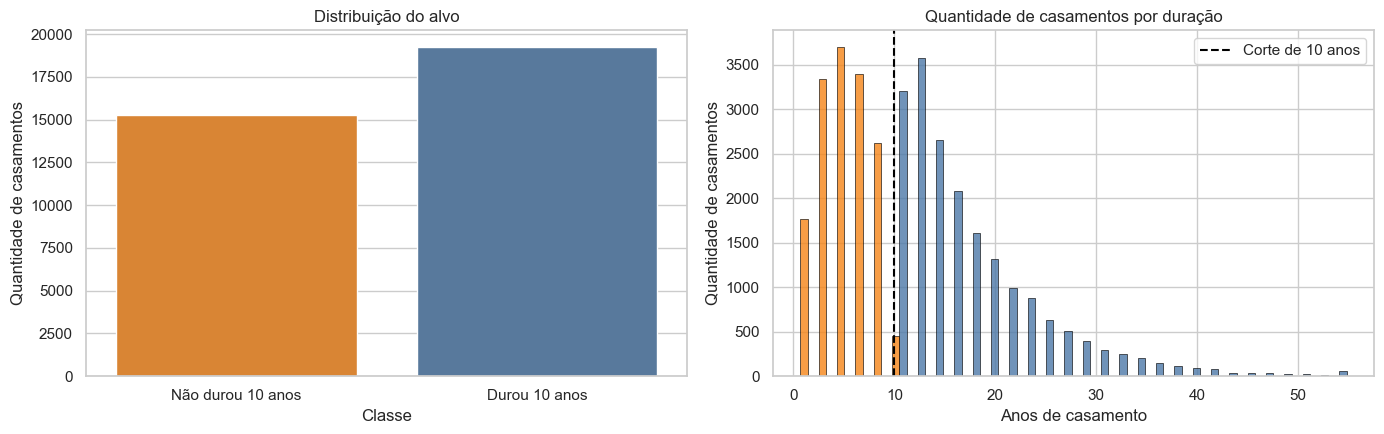

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.countplot(
    data=eligible,
    x='lasted_10_years',
    hue='lasted_10_years',
    palette=['#F58518', '#4C78A8'],
    legend=False,
    ax=axes[0]
)
axes[0].set_xticks([0, 1], ['Não durou 10 anos', 'Durou 10 anos'])
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Quantidade de casamentos')
axes[0].set_title('Distribuição do alvo')

sns.histplot(
    data=eligible,
    x='years_married',
    hue='lasted_10_years',
    bins=30,
    multiple='dodge',
    shrink=0.8,
    alpha=0.8,
    palette=['#F58518', '#4C78A8'],
    edgecolor='black',
    legend=False,
    ax=axes[1]
)

axes[1].axvline(10, color='black', linestyle='--', label='Corte de 10 anos')
axes[1].legend()

axes[1].set_xlabel('Anos de casamento')
axes[1].set_ylabel('Quantidade de casamentos')
axes[1].set_title('Quantidade de casamentos por duração')

plt.tight_layout()
plt.show()

In [11]:
behavioral_features = ['criticism', 'contempt', 'defensiveness', 'stonewalling', 'repair_attempt_success', 'positive_negative_ratio', 'financial_stress', 'shared_activities_weekly']
profile = eligible.groupby('lasted_10_years')[behavioral_features].median().T
profile.columns = ['não durou 10 anos', 'durou 10 anos']
profile['diff'] = profile['durou 10 anos'] - profile['não durou 10 anos']
profile.sort_values('diff')

,não durou 10 anos,durou 10 anos,diff
contempt,4.00,2.90,-1.10
criticism,5.10,4.30,-0.80
defensiveness,5.30,4.60,-0.70
financial_stress,5.70,5.00,-0.70
stonewalling,4.30,3.60,-0.70
positive_negative_ratio,2.66,3.49,0.83
repair_attempt_success,4.90,5.90,1.00
shared_activities_weekly,2.00,3.00,1.00


## Decisões para a modelagem

- Usar 20 características disponíveis antes do desfecho, incluindo sinais comportamentais.
- Aplicar imputação e codificação dentro de um `Pipeline`, para que cada dobra da validação trate os dados sem enxergar a validação.
- Manter uma amostra de teste estratificada de 20% intocada para a avaliação final.
- Comparar os quatro algoritmos permitidos com validação cruzada estratificada de 5 dobras.
- Escolher o modelo pela AUC-ROC média; acurácia balanceada e F1 complementam a leitura.